In [36]:
#!pip install tqdm

In [37]:
import pandas as pd
import re
from tqdm import tqdm  # adding progress bar

# ______________________1. LOADING LABELS (Product names)_______________________

In [38]:
label_map = {}
with open(r'./uchoice-Instacart-labels.txt', encoding='utf-8') as f:
    for line in f:
        matches = re.findall(r'(\d+)\s+(.*)', line.strip())
        if matches:
            item_id = int(matches[0][0])
            label_map[item_id] = matches[0][1]

print(f"Loaded {len(label_map)} product labels")


Loaded 39123 product labels


# ______________________2. LOADING BASKETS (Fast version)_______________________

In [39]:
df = pd.DataFrame(columns=['basket_id','basket'])
baskets = []
print("Loading baskets... most optimal way")

with open(r'./uchoice-Instacart-5-25.txt', encoding='utf-8') as f:
       for line in f:
        if line.strip():
            product_ids = [int(x) for x in line.strip().split()]
            # Converting IDs to actual product names
            product_names = [label_map.get(pid) for pid in product_ids if pid in label_map]
            if product_names:   # skip empty
                baskets.append(product_names)

Loading baskets... most optimal way


In [40]:
# Creating DataFrame
df = pd.DataFrame({
    'basket_id': range(len(baskets)),
    'basket': baskets
})

print(f"\n✅ SUCCESS! Loaded {len(df):,} shopping baskets")
print(f"Example basket:\n{df['basket'].iloc[0]}")
print("\nFirst 5 rows:")
print(df.head())


✅ SUCCESS! Loaded 806,660 shopping baskets
Example basket:
['Michigan Organic Kale', 'Peppermint Stick Ice Cream', 'Italian Dry Salame', 'Organic Raspberry Fruit Spread', 'Dairy Free Gluten Free Mushroom & Roasted Garlic Pizza']

First 5 rows:
   basket_id                                             basket
0          0  [Michigan Organic Kale, Peppermint Stick Ice C...
1          1                [Cage Free  100% Liquid Egg Whites]
2          2  [Mild Diced Green Chiles, Organic Tortilla Chi...
3          3  [Organic Whole Strawberries, Organic Hot Salsa...
4          4  [Chicken & vegetable dumplings with rice in an...


In [41]:
# to optimise my tech capabilities due to large dataset:
# Long format - one row per product purchased

long_data = []
for bid, basket in enumerate(baskets):
    for product in basket:
        long_data.append({'basket_id': bid, 'product': product})

long_df = pd.DataFrame(long_data)
print(long_df.head())
print(f"Total rows: {len(long_df):,}")

   basket_id                                            product
0          0                              Michigan Organic Kale
1          0                         Peppermint Stick Ice Cream
2          0                                 Italian Dry Salame
3          0                     Organic Raspberry Fruit Spread
4          0  Dairy Free Gluten Free Mushroom & Roasted Garl...
Total rows: 2,426,378


In [42]:
#!pip install mlxtend

In [43]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from mlxtend.preprocessing import TransactionEncoder
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ______________________PREPARATION_______________________

In [44]:
#due to 50k x50k the system seems to be crashing at user-user therefore I used sparse matrix for more memory efficient run.
from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity

In [45]:
# Used a sample of 50000 for reasonable speed ( previously tried 30000). We can increase saple size in future.
sample_size = 50000   
sampled_baskets = df['basket'].iloc[:sample_size].tolist()

In [46]:
# Create one-hot matrix for CF
te = TransactionEncoder()
onehot_array = te.fit_transform(sampled_baskets)
ui_matrix = pd.DataFrame(onehot_array, columns=te.columns_)

print(f"User-Item matrix shape: {ui_matrix.shape}")

User-Item matrix shape: (50000, 9118)


In [47]:
# Converting to sparse matrix (much more memory efficient)
ui_sparse = csr_matrix(ui_matrix.values)

print(f"Computing similarity on {sample_size:,} baskets...")

Computing similarity on 50,000 baskets...


### User-User Collaborative Filtering

In [48]:
user_sim = cosine_similarity(ui_sparse, dense_output=False)   # it keep sparse
user_sim = user_sim.toarray()                                 # Only converted final result
np.fill_diagonal(user_sim, 0)

def recommend_user_user(basket_idx, top_n=8):
    sim_scores = user_sim[basket_idx]
    top_similar = np.argsort(sim_scores)[-20:][::-1]   # more neighbours
    scores = sim_scores[top_similar]
    rec_scores = np.dot(scores.reshape(1,-1), ui_matrix.iloc[top_similar].values)[0] / (scores.sum() + 1e-8)
    rec = pd.Series(rec_scores, index=ui_matrix.columns)
    already_bought = set(sampled_baskets[basket_idx])
    return rec[~rec.index.isin(already_bought)].sort_values(ascending=False).head(top_n)

print("User-User Recommendations for basket 0:")
print(recommend_user_user(0))

User-User Recommendations for basket 0:
Organic Whole Strawberries         0.056855
Organic Turmeric Ginger Tonic      0.056855
Max Gel Clog Remover               0.049238
Large Chicken & Cheese Taquitos    0.049238
Sliced White American Cheese       0.049238
Strawberry Rhubarb Yogurt          0.049238
Bag of Organic Bananas             0.049238
Sriracha Chili Sauce               0.049238
dtype: float64


### Item-Item Collaborative Filtering (Recommended for retail)

In [49]:
item_sim = cosine_similarity(ui_matrix.T)
np.fill_diagonal(item_sim, 0)

def recommend_item_item(basket_idx, top_n=8):
    user_vec = ui_matrix.iloc[basket_idx].values.reshape(1, -1)
    scores = np.dot(user_vec, item_sim)[0]
    rec = pd.Series(scores, index=ui_matrix.columns)
    
    already_bought = set(sampled_baskets[basket_idx])
    #rec = rec[~rec.index.isin(already_bought)]
    return rec[~rec.index.isin(already_bought)].sort_values(ascending=False).head(top_n)

print("\nItem-Item CF Recommendations:")
print(recommend_item_item(0))



Item-Item CF Recommendations:
Raspberry Lime Sparkling Water                               0.141421
Sour Batard                                                  0.141421
Organic Lemon Cayenne Sparkling Probiotic Drink              0.115470
Crispy Sea Salt Baked Gourmet Crackers                       0.100000
Natural Mint Gum                                             0.100000
Organic Whole Strawberries                                   0.096323
Potato Puffs with Roasted Garlic and Cracked Black Pepper    0.091047
White Flesh Nectarines                                       0.090576
dtype: float64


## Question 1: _______EXPLANATION/ ANSWER IN THE WORD DOCUMENT REPORT.
Explain the role and significance of recommendation systems in online retail businesses, with a focus on the application of machine learning. Compare and contrast content-based filtering with collaborative filtering, using dataset/ datasets of your own choice. Implement and evaluate the machine learning models for both user-user and item-item collaborative filtering. Provide a justification for your recommendations based on the chosen scenario, highlighting key insights and potential business impact.
Note: Datasets used in the class tutorials or exercises or provided on Moodle for practice are not allowed to use in this integrated CA2 - 

## Question 2: Market Basket Analysis (Apriori vs FP-Growth)

In [50]:
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
# Tried 0.01, 0.003 now lowering to 0.002 for more rules

# Using the same one-hot matrix
onehot_df = ui_matrix.copy()

print("Running Apriori...")
freq_ap = apriori(onehot_df, min_support=0.002, use_colnames=True)   # increased support for better results

print("Running FP-Growth...")
freq_fp = fpgrowth(onehot_df, min_support=0.002, use_colnames=True)

Running Apriori...
Running FP-Growth...


In [51]:
# Generating rules
rules_ap = association_rules(freq_ap, metric="lift", min_threshold=1.2)
rules_fp = association_rules(freq_fp, metric="lift", min_threshold=1.2)

In [52]:
# Fixing the error - Convert lift to numeric. 
# Column 'lift' has dtype object, cannot use method 'nlargest' with this dtype
rules_ap['lift'] = pd.to_numeric(rules_ap['lift'], errors='coerce')
rules_fp['lift'] = pd.to_numeric(rules_fp['lift'], errors='coerce')

In [53]:
# Now safly I can use nlargest
print("=== Top 5 Rules - Apriori ===")
print(rules_ap.nlargest(5, 'lift')[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

print("\n=== Top 5 Rules - FP-Growth ===")
print(rules_fp.nlargest(5, 'lift')[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

=== Top 5 Rules - Apriori ===
                                          antecedents  \
10       (Organic Bakery Hamburger Buns Wheat - 8 CT)   
11                          (Organic Original Hommus)   
0   (Aged White Cheddar Baked Rice & Corn Puffs Gl...   
1                              (Vitamin D Whole Milk)   
5        (Organic Bakery Hamburger Buns Wheat - 8 CT)   

                                          consequents  support  confidence  \
10                          (Organic Original Hommus)  0.00200    0.118624   
11       (Organic Bakery Hamburger Buns Wheat - 8 CT)  0.00200    0.306748   
0                              (Vitamin D Whole Milk)  0.00230    0.380795   
1   (Aged White Cheddar Baked Rice & Corn Puffs Gl...  0.00230    0.103139   
5                        (Grapefruit Sparkling Water)  0.00202    0.119810   

         lift  
10  18.193859  
11  18.193859  
0   17.075996  
1   17.075996  
5    5.411482  

=== Top 5 Rules - FP-Growth ===
                             

## Question 3

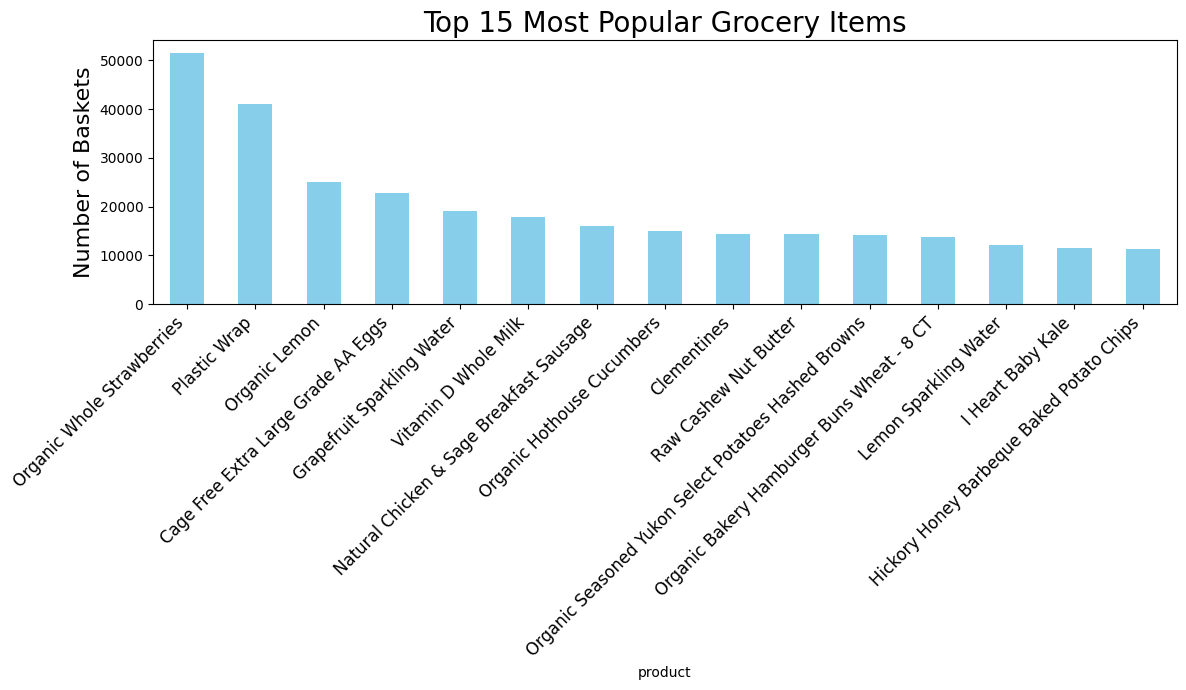

In [54]:
# Top Products
plt.figure(figsize=(12, 7))
long_df['product'].value_counts().head(15).plot(kind='bar', color='skyblue')
plt.title("Top 15 Most Popular Grocery Items", fontsize=20)
plt.ylabel("Number of Baskets", fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.tight_layout()
plt.show()

#### I planned to used the Streamlit but due to 65+ audience I found ChartForgeTK Dashoard to be easier to read and understand by this demographic group

In [55]:
#!pip install ChartForgeTK

In [56]:
import tkinter as tk
from tkinter import ttk
from ChartForgeTK import BarChart, PieChart
import pandas as pd
import random

In [58]:
class GroceryDashboard(tk.Tk):
    def __init__(self, long_df, rules_df=None):
        super().__init__()
        self.title("🛒 Easy Grocery Smart Helper")
        self.geometry("1100x750")

# Making it senior-friendly =================================================================
        self.configure(bg='#f0f0f0')

        notebook = ttk.Notebook(self)
        notebook.pack(fill='both', expand=True, padx=15, pady=15)
        
        tab1 = ttk.Frame(notebook) # Top popular items
        notebook.add(tab1, text="Most Popular Items")

        self.bar_chart = BarChart(tab1, width=1050, height=520)
        self.bar_chart.pack(pady=10)

 # Using dataset ============================================================================
        top_products = long_df['product'].value_counts().head(10)
        self.bar_chart.plot(
            top_products.values.tolist(), 
            top_products.index.tolist()
        )
        
        ttk.Label(tab1, text="Top 10 Most Frequently Bought Grocery Items", 
                  font=("Arial", 14, "bold")).pack(pady=5)
        ttk.Button(tab1, text="Refresh Top Items", command=self.refresh_top_items).pack(pady=8)
        
# TAB 2: Smart Bundles (from MBA) ===========================================================
        tab2 = ttk.Frame(notebook)
        notebook.add(tab2, text="Smart Bundle Suggestions")
        
        self.pie_chart = PieChart(tab2, width=1050, height=520)
        self.pie_chart.pack(pady=10)
 # Example using one of strong rules ========================================================
        bundle_data = [45, 30, 25]
        bundle_labels = ["Organic Hamburger Buns", "Organic Hommus", "Other Items"]
        self.pie_chart.plot(bundle_data, bundle_labels)
        
        ttk.Label(tab2, text="People who buy Organic Hamburger Buns often also buy Organic Hommus", 
                  font=("Arial", 12)).pack(pady=10)
# = TAB 3: Why This Helps Online Shopping ===================================================
        tab3 = ttk.Frame(notebook)
        notebook.add(tab3, text="Why This Helps You")
        
        ttk.Label(tab3, text="Why This Dataset is Great for Smart Shopping", 
                  font=("Arial", 16, "bold")).pack(pady=20)
        
        info_text = """
This grocery dataset contains over 800,000 real shopping baskets.

It helps online shops:
• Show you products you are likely to like
• Suggest useful combinations (bundles)
• Make shopping faster and easier
        """
        ttk.Label(tab3, text=info_text, font=(" Arial", 12), wraplength=900, 
                  justify="left").pack(pady=20)
        
        ttk.Label(tab3, text="Designed with large text and simple tabs for easy use by adults 65+", 
                  font=(" Arial", 12), foreground="blue").pack(pady=30)
        
     def refresh_top_items(self):
        # Optional: refresh with slightly different top items
        top_products = long_df['product'].value_counts().head(10)
        self.bar_chart.plot(
            top_products.values.tolist(), 
            top_products.index.tolist()
        )
         
if __name__ == "__main__":
    # Please NOTE: make sure 'long_df' exists in your Jupyter session n case you want to run this instead of display only
    app = GroceryDashboard(long_df)
    app.mainloop()

IndentationError: unindent does not match any outer indentation level (<string>, line 64)